In [1]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from mplsoccer import Pitch, VerticalPitch
except:
    %pip install mplsoccer
    import pandas as pd
    import matplotlib.pyplot as plt
    from mplsoccer import Pitch, VerticalPitch    

In [2]:
eventsMessi = pd.read_csv('eventsMessi.csv')

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_31336\1308467389.py:1: DtypeWarning: Columns (1,4,5,6,7,10,12,13,14,16,17,18,19,28,40,42,44,46,49,50,64,65,66,67,68,69,70,71,73,74,75,76,83,84,85,86,88,89,90,91,92,93,97,98,99,100,101,102,103,104,105,106,107,113) have mixed types. Specify dtype option on import or set low_memory=False.
  eventsMessi = pd.read_csv('eventsMessi.csv')


In [3]:
seasons = sorted(eventsMessi['season'].unique().tolist())

In [4]:
col = eventsMessi.columns.tolist()

initialYears = pd.DataFrame(columns=col)
pepYears = pd.DataFrame(columns=col)
msnYears = pd.DataFrame(columns=col)
swanSong = pd.DataFrame(columns=col)

dfList = []

for season in seasons:
    if(season=='2004/2005' or season=='2005/2006'
       or season=='2006/2007' or season=='2007/2008'):
        initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2008/2009' or season=='2009/2010'
       or season=='2010/2011' or season=='2011/2012'):
        pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
        
    elif(season=='2012/2013' or season=='2013/2014'
       or season=='2015/2016' or season=='2016/2017'):
        msnYears = pd.concat([msnYears,eventsMessi[eventsMessi['season']==season]])
    
    else:
        swanSong = pd.concat([swanSong,eventsMessi[eventsMessi['season']==season]]) 
    

C:\Users\yashaswi\AppData\Local\Temp\ipykernel_31336\3364662301.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  initialYears = pd.concat([initialYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_31336\3364662301.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pepYears = pd.concat([pepYears,eventsMessi[eventsMessi['season']==season]])
C:\Users\yashaswi\AppData\Local\Temp\ipykernel_31336\3364662301.py:21: FutureWarning: The behavior of Data

In [5]:
passesIY = initialYears[initialYears['type']=='Pass']
passesPY = pepYears[pepYears['type']=='Pass']
passesMY = msnYears[msnYears['type']=='Pass']
passesSS = swanSong[swanSong['type']=='Pass']

In [6]:
sPIY = passesIY[passesIY['pass_outcome'].isna()]
sPPY = passesPY[passesPY['pass_outcome'].isna()]
sPMY = passesMY[passesMY['pass_outcome'].isna()]
sPSS = passesSS[passesSS['pass_outcome'].isna()]

## Initial Years

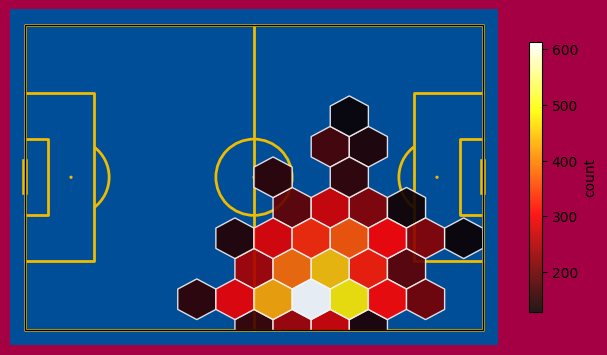

In [5]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')

fig, ax = pitch.draw()

fig.set_facecolor('#a50044')
hexmap = pitch.hexbin(initialYears['x_start'], initialYears['y_start'], ax=ax, edgecolors='#f4f4f4',
                      alpha=0.9, gridsize=(12, 5), cmap='hot',mincnt=125)

cbar = fig.colorbar(hexmap, ax=ax, shrink=0.6,label='count')

### Passing

In [6]:
passesIY = initialYears[initialYears['type']=='Pass']
sPIY = passesIY[passesIY['pass_outcome'].isna()]

In [34]:
topRecip = sPIY['pass_recipient'].value_counts().rename_axis('player_name').reset_index(name='counts').head(5)

In [35]:
topRecip

,player_name,counts
0,Xavier Hernández Creus,354
1,Anderson Luís de Souza,297
2,Ronaldo de Assis Moreira,284
3,Andrés Iniesta Luján,160
4,Samuel Eto''o Fils,157


In [138]:
iCarry = initialYears[initialYears['type']=='Carry']

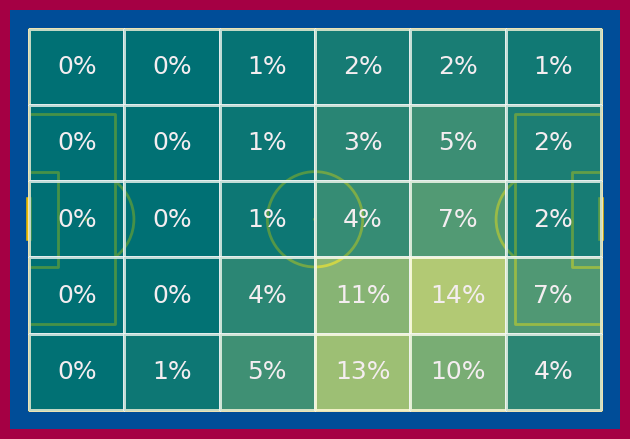

In [127]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
fig, ax = pitch.draw()
fig.set_facecolor('#a50044')
bin_statistic = pitch.bin_statistic(initialYears['x_carry_end'], initialYears['y_carry_end'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='summer', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}')

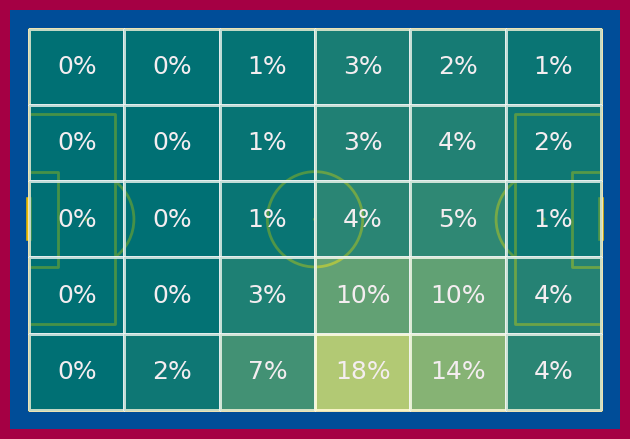

In [139]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00')
fig, ax = pitch.draw()
fig.set_facecolor('#a50044')
bin_statistic = pitch.bin_statistic(iCarry['x_start'], iCarry['y_start'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='summer', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}')

In [22]:
passesIY = initialYears[initialYears['type']=='Pass']
sPIY = passesIY[passesIY['pass_outcome'].isna()]

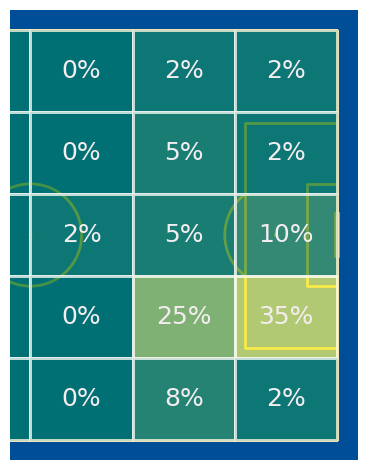

In [143]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, ax = pitch.draw()

bin_statistic = pitch.bin_statistic(dangerPasses['x_start'], dangerPasses['y_start'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='summer', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}')

In [119]:
from matplotlib.patches import Circle
circH = Circle((120.0, 40.0), radius = 15,color='red')
circV = Circle((40.0, 120.0), radius = 15,color='red')

In [120]:
dangerPass = [row['id'] for index,row in sPIY.iterrows() if ((circH.contains_point([row['x_end'],row['y_end']])==True) or 
                                                             (circV.contains_point([row['x_end'],row['y_end']])==True))]

In [121]:
dangerPasses = sPIY[sPIY['id'].isin(dangerPass)]

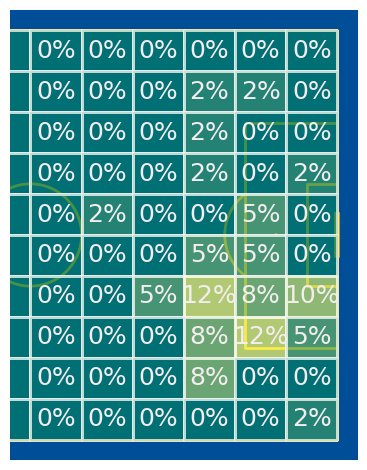

In [144]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, ax = pitch.draw()

bin_statistic = pitch.bin_statistic(dangerPasses['x_start'], dangerPasses['y_start'], statistic='count', bins=(12, 10), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='summer', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}')

In [141]:
iDribbles = initialYears[initialYears['type']=='Dribble']

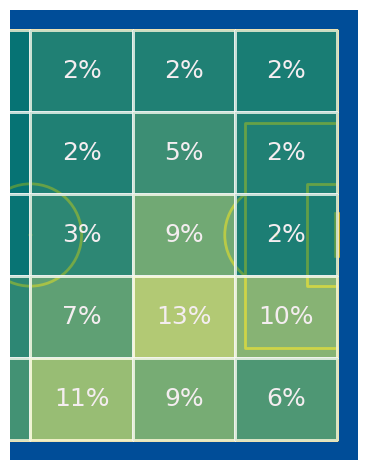

In [142]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='#004d98', line_color='#edbb00',half=True)

fig, ax = pitch.draw()

bin_statistic = pitch.bin_statistic(iDribbles['x_start'], iDribbles['y_start'], statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='summer', edgecolor='#f9f9f9',alpha=0.7)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}')

In [10]:
goalsIY = initialYears[initialYears['type']=='Shot']
goalsPY = pepYears[pepYears['type']=='Shot']
goalsMY = msnYears[msnYears['type']=='Shot']
goalsSS = swanSong[swanSong['type']=='Shot']

sGIY = goalsIY[goalsIY['pass_outcome'].isna()]
sGPY = goalsPY[goalsPY['pass_outcome'].isna()]
sGMY = goalsMY[goalsMY['pass_outcome'].isna()]
sGSS = goalsSS[goalsSS['pass_outcome'].isna()]

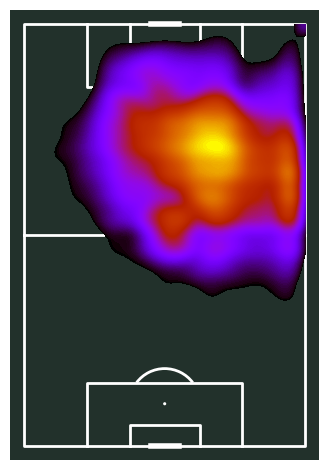

In [12]:
pitch = VerticalPitch(pitch_type='statsbomb',pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw()

kde = pitch.kdeplot(eventsMessi['x_start'],eventsMessi['y_start'],fill=True,n_levels=200,thresh=0.1,cmap='gnuplot',ax=ax)